# Senior Batch Assessment

**Name :G.Sree Ganesh Ram  
**Roll Number:2531 
**Batch:** Senior Batch

**Duration allowed:** 2.5 hours  
**Submit:** One notebook and all required output files in one zip folder


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## Dataset paths

- `datasets/pandas/fortune1000.csv`
- `datasets/pandas/restaurant_foods.csv`
- `datasets/pandas/restaurant_week_1_sales.csv`
- `datasets/pandas/restaurant_week_2_sales.csv`
- `datasets/pandas/nba.csv`
- `datasets/dataviz/HotelCustomersDataset.xlsx`


## Q1. Python Function — Next Palindrome

Write a function:

```python
def next_palindrome(num):
    ...
```

Return the **next palindrome strictly greater than** the input number.

Test using:
```python
next_palindrome(90)
next_palindrome(123)
next_palindrome(808)
```

**Write your solution below.**

In [4]:
import sys

def next_palindrome(num):
    numStr = str(num)
    for i in range(num + 1, sys.maxsize):
        if str(i) == str(i)[::-1]:            
            return i

In [7]:
n1=next_palindrome(90)
print(n1)
n2=next_palindrome(123)
print(n2)
n3=next_palindrome(808)
print(n3)

99
131
818


## Q2. Python Function — Frequency Dictionary

Write a function:

```python
def word_frequency(text):
    ...
```

Rules:
- convert the text to lowercase
- remove commas and full stops
- split into words
- return a dictionary of word counts

Test using:
```python
sample_text = "Python is simple. Python is powerful, and Python is fun."
```

**Write your solution below.**

In [9]:
def word_frequency(text):
    text = text.lower()
    text = text.replace(",", "").replace(".", "")
    words = text.split()
    freq = {}
    for word in words:
        freq[word] = freq.get(word, 0) + 1
    
    return freq

word_frequency("Python is simple. Python is powerful, and Python is fun.")   

{'python': 3, 'is': 3, 'simple': 1, 'powerful': 1, 'and': 1, 'fun': 1}

## Q3. Fortune 1000 — Sector Profit Summary

Use `datasets/pandas/fortune1000.csv`

Tasks:
1. Keep only rows where `Profits > 0` and `Revenue >= 50000`
2. Group by `Sector`
3. Create output columns: `company_count`, `avg_revenue`, `total_profits`
4. Sort by `total_profits` descending, then `avg_revenue` descending
5. Save the top 5 rows to `q3_sector_profit_summary.csv`

**Write your solution below.**

In [8]:
import pandas as pd
import numpy as np

In [22]:
df=pd.read_csv("datasets/pandas/fortune1000.csv")
df.head()

,Rank,Company,Sector,Industry,Revenue,Profits,Employees
0,1,Walmart,Retailing,General Merchandisers,482130,14694,2300000
1,2,Exxon Mobil,Energy,Petroleum Refining,246204,16150,75600
2,3,Apple,Technology,"Computers, Office Equipment",233715,53394,110000
3,4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),210821,24083,331000
4,5,McKesson,Health Care,Wholesalers: Health Care,181241,1476,70400


In [30]:
#Q1
q1 = df[(df["Profits"] > 0) & (df["Revenue"] >= 5000)]
q1

,Rank,Company,Sector,Industry,Revenue,Profits,Employees
0,1,Walmart,Retailing,General Merchandisers,482130,14694,2300000
1,2,Exxon Mobil,Energy,Petroleum Refining,246204,16150,75600
2,3,Apple,Technology,"Computers, Office Equipment",233715,53394,110000
3,4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),210821,24083,331000
4,5,McKesson,Health Care,Wholesalers: Health Care,181241,1476,70400
...,...,...,...,...,...,...,...
504,505,Harris,Technology,Network and Other Communications Equipment,5083,334,22300
505,506,Hanover Insurance Group,Financials,Insurance: Property and Casualty (Stock),5034,332,4800
506,507,Pepco Holdings,Energy,Utilities: Gas and Electric,5023,327,5184
507,508,Nvidia,Technology,Semiconductors and Other Electronic Components,5010,614,9227


In [34]:
# Q2 and Q3
q23=q1.groupby("Sector").agg(company_count=("Company","count"),avg_revenue=("Revenue","mean"),total_profit=("Profits","sum"))
q23

,company_count,avg_revenue,total_profit
Sector,,,
Aerospace & Defense,11,29449.090909,27524
Apparel,5,12870.000000,6208
Business Services,19,9134.842105,21532
Chemicals,11,16495.090909,20180
Energy,44,25402.136364,67697
Engineering & Construction,11,8680.363636,4164
Financials,80,25113.025000,238677
Food and Drug Stores,7,65560.000000,16298
"Food, Beverages & Tobacco",23,20512.826087,47355


In [40]:
top5=q23.head(5).to_csv("q3_sector_profit_summary.csv")
top5

## Q4. Fortune 1000 — Company Efficiency Score

Use `datasets/pandas/fortune1000.csv`

Tasks:
1. Keep only rows where `Employees > 0` and `Revenue > 0`
2. Create `revenue_per_employee = Revenue / Employees`
3. Keep columns: `Company`, `Sector`, `Revenue`, `Employees`, `revenue_per_employee`
4. Sort by `revenue_per_employee` descending
5. Save the top 10 rows to `q4_top_companies_efficiency.csv`

**Write your solution below.**

In [41]:
#Q1
q1 = df[(df["Employees"] > 0) & (df["Revenue"] >0)]
q1

,Rank,Company,Sector,Industry,Revenue,Profits,Employees
0,1,Walmart,Retailing,General Merchandisers,482130,14694,2300000
1,2,Exxon Mobil,Energy,Petroleum Refining,246204,16150,75600
2,3,Apple,Technology,"Computers, Office Equipment",233715,53394,110000
3,4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),210821,24083,331000
4,5,McKesson,Health Care,Wholesalers: Health Care,181241,1476,70400
...,...,...,...,...,...,...,...
995,996,New York Community Bancorp,Financials,Commercial Banks,1902,-47,3448
996,997,Portland General Electric,Energy,Utilities: Gas and Electric,1898,172,2646
997,997,Portland General Electric,Energy,Utilities: Gas and Electric,1898,172,2646
998,999,Wendy’s,"Hotels, Resturants & Leisure",Food Services,1896,161,21200


In [42]:
df['revenue_per_employee']=df['Revenue']/df['Employees']
df.head()

,Rank,Company,Sector,Industry,Revenue,Profits,Employees,revenue_per_employee
0,1,Walmart,Retailing,General Merchandisers,482130,14694,2300000,0.209622
1,2,Exxon Mobil,Energy,Petroleum Refining,246204,16150,75600,3.256667
2,3,Apple,Technology,"Computers, Office Equipment",233715,53394,110000,2.124682
3,4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),210821,24083,331000,0.636921
4,5,McKesson,Health Care,Wholesalers: Health Care,181241,1476,70400,2.574446


In [44]:
q3 = df[
    ["Company", "Sector", "Revenue", "Employees", "revenue_per_employee"]]
q3

,Company,Sector,Revenue,Employees,revenue_per_employee
0,Walmart,Retailing,482130,2300000,0.209622
1,Exxon Mobil,Energy,246204,75600,3.256667
2,Apple,Technology,233715,110000,2.124682
3,Berkshire Hathaway,Financials,210821,331000,0.636921
4,McKesson,Health Care,181241,70400,2.574446
...,...,...,...,...,...
995,New York Community Bancorp,Financials,1902,3448,0.551624
996,Portland General Electric,Energy,1898,2646,0.717309
997,Portland General Electric,Energy,1898,2646,0.717309
998,Wendy’s,"Hotels, Resturants & Leisure",1896,21200,0.089434


In [45]:
q4=q3.sort_values(by='revenue_per_employee',ascending=False)
q4

,Company,Sector,Revenue,Employees,revenue_per_employee
425,A-Mark Precious Metals,Materials,6070,52,116.730769
82,INTL FCStone,Financials,34693,1231,28.182778
472,Host Hotels & Resorts,Financials,5387,240,22.445833
471,Host Hotels & Resorts,Financials,5387,240,22.445833
15,Fannie Mae,Financials,110359,7300,15.117671
...,...,...,...,...,...
556,Bloomin’ Brands,"Hotels, Resturants & Leisure",4378,100000,0.043780
762,Cracker Barrel Old Country Store,"Hotels, Resturants & Leisure",2842,72000,0.039472
443,Starwood Hotels & Resorts,"Hotels, Resturants & Leisure",5763,188000,0.030654
217,Yum Brands,"Hotels, Resturants & Leisure",13105,505000,0.025950


In [46]:
top10=q4.head(10).to_csv("q4_top_companies_efficiency.csv")
top10

## Q5. Restaurant Data — Food Revenue Summary

Use:
- `datasets/pandas/restaurant_foods.csv`
- `datasets/pandas/restaurant_week_1_sales.csv`
- `datasets/pandas/restaurant_week_2_sales.csv`

Tasks:
1. Combine both weekly sales files
2. Merge with the food master file
3. Create summary by `Food Item` with `orders`, `unit_price`, `revenue`
4. Sort by `orders` descending, then `revenue` descending
5. Save the top 5 rows to `q5_food_revenue.csv`

**Write your solution below.**

In [47]:
df2=pd.read_csv("datasets/pandas/restaurant_foods.csv")
df2

,Food ID,Food Item,Price
0,1,Sushi,3.99
1,2,Burrito,9.99
2,3,Taco,2.99
3,4,Quesadilla,4.25
4,5,Pizza,2.49
5,6,Pasta,13.99
6,7,Steak,24.99
7,8,Salad,11.25
8,9,Donut,0.99
9,10,Drink,1.75


In [48]:
df3=pd.read_csv("datasets/pandas/restaurant_week_1_sales.csv")
df3

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9
...,...,...
245,413,9
246,926,6
247,134,3
248,396,6


In [49]:
df4=pd.read_csv("datasets/pandas/restaurant_week_2_sales.csv")
df4

,Customer ID,Food ID
0,688,10
1,813,7
2,495,10
3,189,5
4,267,3
...,...,...
245,783,10
246,556,10
247,547,9
248,252,9


In [57]:
#q1
q1=df3.merge(df4,how='left',on='Food ID')
q1

,Customer ID_x,Food ID,Customer ID_y
0,537,9,729
1,537,9,732
2,537,9,381
3,537,9,379
4,537,9,574
...,...,...,...
6218,535,10,463
6219,535,10,734
6220,535,10,559
6221,535,10,783


In [58]:
#q2
q2=q1.merge(df2,how='left',on='Food ID')
q2

,Customer ID_x,Food ID,Customer ID_y,Food Item,Price
0,537,9,729,Donut,0.99
1,537,9,732,Donut,0.99
2,537,9,381,Donut,0.99
3,537,9,379,Donut,0.99
4,537,9,574,Donut,0.99
...,...,...,...,...,...
6218,535,10,463,Drink,1.75
6219,535,10,734,Drink,1.75
6220,535,10,559,Drink,1.75
6221,535,10,783,Drink,1.75


In [62]:
summary = (q2.groupby("Food Item").agg(orders=("Food ID", "count"),unit_price=("Price", "first"),revenue=("Price", "sum")))
summary

,orders,unit_price,revenue
Food Item,,,
Burrito,806,9.99,8051.94
Donut,700,0.99,693.00
Drink,840,1.75,1470.00
Pasta,728,13.99,10184.72
Pizza,380,2.49,946.20
Quesadilla,588,4.25,2499.00
Salad,575,11.25,6468.75
Steak,621,24.99,15518.79
Sushi,456,3.99,1819.44


In [68]:
q4=summary.sort_values(by=['orders','revenue'],ascending=[False,False])
q4

,orders,unit_price,revenue
Food Item,,,
Drink,840,1.75,1470.00
Burrito,806,9.99,8051.94
Pasta,728,13.99,10184.72
Donut,700,0.99,693.00
Steak,621,24.99,15518.79
Quesadilla,588,4.25,2499.00
Salad,575,11.25,6468.75
Taco,529,2.99,1581.71
Sushi,456,3.99,1819.44


In [69]:
top5=q4.to_csv("q5_food_revenue.csv")
top5

## Q6. Restaurant Data — Top Customers by Spend

Use the same 3 restaurant datasets.

Tasks:
1. Combine both weekly sales files
2. Merge with the food master file
3. Create customer summary with `Customer ID`, `total_orders`, `total_spend`
4. Sort by `total_spend` descending, then `total_orders` descending
5. Save the top 10 rows to `q6_top_customers.csv`

**Write your solution below.**

In [74]:
summary = (q2.groupby("Customer ID_x").agg(total_orders=("Food ID", "sum"),total_spend=("Price", "sum")))
summary

,total_orders,total_spend
Customer ID_x,,
3,62,309.69
10,62,309.69
20,19,75.81
21,224,238.00
26,180,19.80
...,...,...
966,100,49.80
968,19,75.81
985,100,49.80


In [75]:
q4=summary.sort_values(by=['total_orders','total_spend'],ascending=[False,False])
q4

,total_orders,total_spend
Customer ID_x,,
250,511,636.02
772,511,636.02
809,511,636.02
77,441,425.10
226,419,130.02
...,...,...
703,19,75.81
922,19,75.81
953,19,75.81


In [103]:
top10=q4.head(10).to_csv("q6_top_customers.csv")
top10

## Q7. NBA Data — College Salary Analysis

Use `datasets/pandas/nba.csv`

Tasks:
1. Remove rows where `Salary` or `College` is null
2. Group by `College`
3. Calculate `players` and `avg_salary`
4. Keep only colleges with at least 5 players
5. Sort by `avg_salary` descending
6. Save the top 5 rows to `q7_college_salary.csv`

**Write your solution below.**

In [3]:
df5=pd.read_csv("datasets/pandas/nba.csv")
df5

,Name,Team,Position,Height,Weight,College,Salary
0,Saddiq Bey,Atlanta Hawks,F,6-7,215.0,Villanova,4556983.0
1,Bogdan Bogdanovic,Atlanta Hawks,G,6-5,225.0,Fenerbahce,18700000.0
2,Kobe Bufkin,Atlanta Hawks,G,6-5,195.0,Michigan,4094244.0
3,Clint Capela,Atlanta Hawks,C,6-10,256.0,Elan Chalon,20616000.0
4,Bruno Fernando,Atlanta Hawks,F-C,6-10,240.0,Maryland,2581522.0
...,...,...,...,...,...,...,...
587,Ryan Rollins,Washington Wizards,G,6-3,180.0,Toledo,1719864.0
588,Landry Shamet,Washington Wizards,G,6-4,190.0,Wichita State,10250000.0
589,Tristan Vukcevic,Washington Wizards,F,6-10,220.0,Real Madrid,NaN
590,Delon Wright,Washington Wizards,G,6-5,185.0,Utah,8195122.0


In [98]:
q1 = df5.dropna(subset=["Salary", "College"])
q1

,Name,Team,Position,Height,Weight,College,Salary
0,Saddiq Bey,Atlanta Hawks,F,6-7,215.0,Villanova,4556983.0
1,Bogdan Bogdanovic,Atlanta Hawks,G,6-5,225.0,Fenerbahce,18700000.0
2,Kobe Bufkin,Atlanta Hawks,G,6-5,195.0,Michigan,4094244.0
3,Clint Capela,Atlanta Hawks,C,6-10,256.0,Elan Chalon,20616000.0
4,Bruno Fernando,Atlanta Hawks,F-C,6-10,240.0,Maryland,2581522.0
...,...,...,...,...,...,...,...
585,Eugene Omoruyi,Washington Wizards,F,6-6,235.0,Oregon,559782.0
586,Jordan Poole,Washington Wizards,G,6-4,194.0,Michigan,27955357.0
587,Ryan Rollins,Washington Wizards,G,6-3,180.0,Toledo,1719864.0
588,Landry Shamet,Washington Wizards,G,6-4,190.0,Wichita State,10250000.0


In [99]:
summary = (q1.groupby("College").agg(players=("Name", "count"),avg_salary=("Salary", "mean")))
summary

,players,avg_salary
College,,
Alabama,5,6.482878e+06
Anadolu Efes,3,4.933020e+06
Arizona,9,1.040041e+07
Arizona State,3,1.780099e+07
Arkansas,9,5.043533e+06
...,...,...
Winthrop,1,1.719864e+06
Wisconsin,2,2.805291e+06
Wisconsin-Milwaukee,1,2.337720e+06


In [100]:
filtered=summary[summary['players']>=5]
filtered

,players,avg_salary
College,,
Alabama,5,6.482878e+06
Arizona,9,1.040041e+07
Arkansas,9,5.043533e+06
Baylor,7,4.200849e+06
Duke,18,1.372397e+07
Florida,6,1.249743e+07
Florida State,7,7.846875e+06
Gonzaga,11,9.616227e+06
Houston,5,2.729739e+06


In [102]:
q4=filtered.sort_values(by='avg_salary',ascending=False)
q4

,players,avg_salary
College,,
Kentucky,23,1.618677e+07
Duke,18,1.372397e+07
Villanova,8,1.357575e+07
Louisville,5,1.283732e+07
Mega Basket,5,1.270381e+07
Florida,6,1.249743e+07
Kansas,7,1.209390e+07
Texas,9,1.131867e+07
UCLA,14,1.059118e+07


In [104]:
q5=q4.head(5).to_csv("q7_college_salary.csv")
q5

## Q8. NBA Data — Team and Position Salary Matrix

Use `datasets/pandas/nba.csv`

Tasks:
1. Remove rows where `Salary` is null
2. Create a pivot table with:
   - `index = Team`
   - `columns = Position`
   - `values = Salary`
   - `aggfunc = mean`
3. Fill missing values with 0
4. Round to 2 decimals
5. Save the full pivot table to `q8_team_position_salary.csv`

**Write your solution below.**

In [5]:
df5.isnull().sum()

Name          1
Team          1
Position      8
Height        7
Weight        8
College      14
Salary      104
dtype: int64

In [6]:
q1 = df5.dropna(subset=["Salary"])
q1

,Name,Team,Position,Height,Weight,College,Salary
0,Saddiq Bey,Atlanta Hawks,F,6-7,215.0,Villanova,4556983.0
1,Bogdan Bogdanovic,Atlanta Hawks,G,6-5,225.0,Fenerbahce,18700000.0
2,Kobe Bufkin,Atlanta Hawks,G,6-5,195.0,Michigan,4094244.0
3,Clint Capela,Atlanta Hawks,C,6-10,256.0,Elan Chalon,20616000.0
4,Bruno Fernando,Atlanta Hawks,F-C,6-10,240.0,Maryland,2581522.0
...,...,...,...,...,...,...,...
585,Eugene Omoruyi,Washington Wizards,F,6-6,235.0,Oregon,559782.0
586,Jordan Poole,Washington Wizards,G,6-4,194.0,Michigan,27955357.0
587,Ryan Rollins,Washington Wizards,G,6-3,180.0,Toledo,1719864.0
588,Landry Shamet,Washington Wizards,G,6-4,190.0,Wichita State,10250000.0


In [7]:
q2=pd.pivot_table(q1,index = 'Team',columns = 'Position',values = 'Salary',aggfunc = 'mean')
q2

Position,C,C-F,F,F-C,F-G,G,G-F
Team,,,,,,,
Atlanta Hawks,2.061600e+07,NaN,3.078706e+06,5.345292e+06,20089286.0,1.046006e+07,NaN
Boston Celtics,NaN,6206652.0,1.973801e+06,3.601620e+07,17382530.0,7.855591e+06,3.183036e+07
Brooklyn Nets,2.210040e+06,NaN,7.488918e+06,NaN,NaN,7.719028e+06,2.979670e+07
Charlotte Hornets,3.908160e+06,3047880.0,1.004292e+07,NaN,NaN,7.247302e+06,NaN
Chicago Bulls,1.093926e+07,NaN,2.922021e+06,NaN,NaN,1.367147e+07,2.860000e+07
Cleveland Cavaliers,1.048977e+07,NaN,3.306521e+06,5.709877e+06,8920794.0,1.520921e+07,8.463354e+06
Dallas Mavericks,NaN,NaN,9.546185e+06,4.000000e+06,40064220.0,1.010445e+07,2.019706e+06
Denver Nuggets,1.712119e+07,NaN,6.544972e+06,4.306281e+06,3196448.0,7.178834e+06,NaN
Detroit Pistons,8.225060e+06,NaN,6.189357e+06,5.266713e+06,NaN,5.768854e+06,1.395300e+07


In [8]:
q3=q1.fillna(0)
q3

,Name,Team,Position,Height,Weight,College,Salary
0,Saddiq Bey,Atlanta Hawks,F,6-7,215.0,Villanova,4556983.0
1,Bogdan Bogdanovic,Atlanta Hawks,G,6-5,225.0,Fenerbahce,18700000.0
2,Kobe Bufkin,Atlanta Hawks,G,6-5,195.0,Michigan,4094244.0
3,Clint Capela,Atlanta Hawks,C,6-10,256.0,Elan Chalon,20616000.0
4,Bruno Fernando,Atlanta Hawks,F-C,6-10,240.0,Maryland,2581522.0
...,...,...,...,...,...,...,...
585,Eugene Omoruyi,Washington Wizards,F,6-6,235.0,Oregon,559782.0
586,Jordan Poole,Washington Wizards,G,6-4,194.0,Michigan,27955357.0
587,Ryan Rollins,Washington Wizards,G,6-3,180.0,Toledo,1719864.0
588,Landry Shamet,Washington Wizards,G,6-4,190.0,Wichita State,10250000.0


In [9]:
q5=q2.to_csv("q8_team_position_salary.csv")
q5

## Q9. Hotel Data — Top 5 Nationalities by Lodging Revenue

Use `datasets/dataviz/HotelCustomersDataset.xlsx`

Tasks:
1. Group by `Nationality`
2. Compute total `LodgingRevenue`
3. Select the top 5 nationalities
4. Create a bar chart
5. Save the chart as `q9_top5_lodging_revenue.png`

Chart rules:
- title required
- x-axis = nationality
- y-axis = total lodging revenue
- labels must be readable

**Write your solution below.**

In [11]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [2]:
df6=pd.read_excel("datasets/dataviz/HotelCustomersDataset.xlsx")
df6

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,RoomNights,DaysSinceLastStay,DaysSinceFirstStay,DistributionChannel,MarketSegment,SRHighFloor,SRLowFloor,SRAccessibleRoom,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,8,5,151,1074,Corporate,Corporate,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,10,5,1100,1100,Travel Agent/Operator,Travel Agent/Operator,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Travel Agent/Operator,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,10,5,1100,1100,Travel Agent/Operator,Travel Agent/Operator,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Travel Agent/Operator,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83585,83586,ITA,54.0,0,0,0.0,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Other,0,0,0,0,0,0,0,0,0,0,0,0,0
83586,83587,IRL,47.0,0,109,327.1,277.5,0,0,1,6,3,3,3,Travel Agent/Operator,Other,0,0,0,0,0,0,0,1,0,0,0,0,0
83587,83588,IRL,53.0,0,0,0.0,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Other,0,0,0,0,0,0,0,1,0,0,0,0,0
83588,83589,IRL,85.0,0,109,981.3,9.0,0,0,1,6,3,3,3,Travel Agent/Operator,Other,0,0,0,0,0,0,0,0,1,0,0,0,0


In [4]:
q1=df6.groupby('Nationality')['LodgingRevenue'].sum()
q1

Nationality
ABW     1896.52
AGO    96436.72
AIA     1164.60
ALB     3455.90
AND     3107.40
         ...   
WLF      135.20
WSM      314.00
YEM        0.00
ZAF    20328.68
ZWE      684.00
Name: LodgingRevenue, Length: 188, dtype: float64

In [5]:
q2=df6.sort_values(by='LodgingRevenue',ascending=False)
q2

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,RoomNights,DaysSinceLastStay,DaysSinceFirstStay,DistributionChannel,MarketSegment,SRHighFloor,SRLowFloor,SRAccessibleRoom,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
2757,2758,PRT,NaN,1025,57,21781.00,1584.0,1,0,29,62,185,777,1036,Corporate,Direct,0,0,0,0,0,0,0,0,0,0,0,0,0
23964,23965,USA,23.0,659,7,9682.40,1300.0,0,0,1,12,6,665,665,Travel Agent/Operator,Other,0,0,0,0,0,0,0,0,0,0,0,0,0
42497,42498,DEU,51.0,379,65,9665.66,2265.0,0,0,1,10,5,384,384,Travel Agent/Operator,Travel Agent/Operator,0,0,0,0,0,0,0,0,0,0,0,0,0
38713,38714,NAM,62.0,444,2,9180.00,1144.5,1,0,2,16,8,147,452,Direct,Direct,0,0,0,0,0,0,0,0,0,0,0,0,0
73417,73418,GBR,55.0,100,39,9010.00,566.8,0,0,2,4,4,100,101,Travel Agent/Operator,Groups,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,20,FRA,26.0,1095,0,0.00,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Travel Agent/Operator,1,0,0,0,0,0,0,1,0,0,0,0,0
17,18,FRA,71.0,1095,0,0.00,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Travel Agent/Operator,0,0,0,0,0,0,0,0,0,0,0,0,0
83563,83564,ITA,9.0,0,0,0.00,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Other,0,0,0,0,0,0,0,0,0,0,0,0,0
61694,61695,AUT,54.0,185,0,0.00,0.0,0,0,0,0,0,-1,-1,Travel Agent/Operator,Other,0,0,0,0,0,0,0,1,0,0,0,0,0


In [6]:
q3=q2.head()
q3

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,RoomNights,DaysSinceLastStay,DaysSinceFirstStay,DistributionChannel,MarketSegment,SRHighFloor,SRLowFloor,SRAccessibleRoom,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
2757,2758,PRT,NaN,1025,57,21781.00,1584.0,1,0,29,62,185,777,1036,Corporate,Direct,0,0,0,0,0,0,0,0,0,0,0,0,0
23964,23965,USA,23.0,659,7,9682.40,1300.0,0,0,1,12,6,665,665,Travel Agent/Operator,Other,0,0,0,0,0,0,0,0,0,0,0,0,0
42497,42498,DEU,51.0,379,65,9665.66,2265.0,0,0,1,10,5,384,384,Travel Agent/Operator,Travel Agent/Operator,0,0,0,0,0,0,0,0,0,0,0,0,0
38713,38714,NAM,62.0,444,2,9180.00,1144.5,1,0,2,16,8,147,452,Direct,Direct,0,0,0,0,0,0,0,0,0,0,0,0,0
73417,73418,GBR,55.0,100,39,9010.00,566.8,0,0,2,4,4,100,101,Travel Agent/Operator,Groups,0,0,0,0,0,0,0,0,0,0,0,0,0


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '2757'),
  Text(1, 0, '23964'),
  Text(2, 0, '42497'),
  Text(3, 0, '38713'),
  Text(4, 0, '73417')])

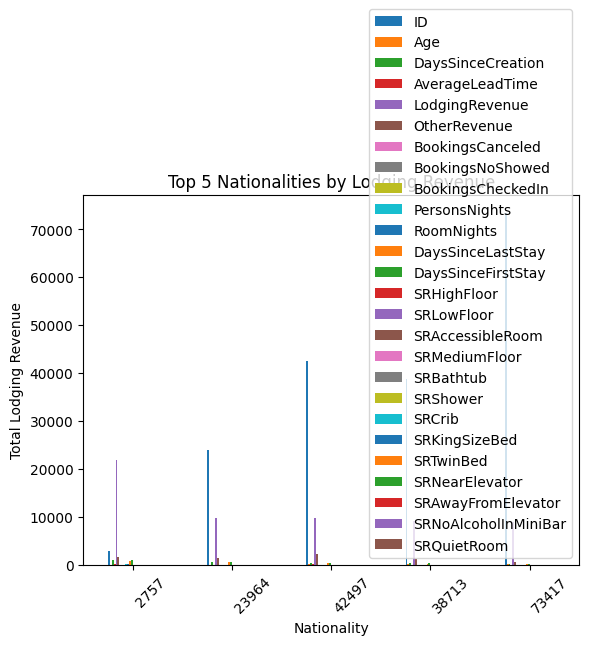

In [8]:
q3.plot(kind="bar")
plt.title("Top 5 Nationalities by Lodging Revenue")
plt.xlabel("Nationality")
plt.ylabel("Total Lodging Revenue")
plt.xticks(rotation=45, ha="left")

In [9]:
plt.tight_layout()
plt.savefig("q9_top5_lodging_revenue.png")
plt.show()

<Figure size 640x480 with 0 Axes>

## Q10. Hotel Data — Market Segment Booking Mix

Use `datasets/dataviz/HotelCustomersDataset.xlsx`

Tasks:
1. Group by `MarketSegment`
2. Calculate total `BookingsCheckedIn`, `BookingsCanceled`, and `BookingsNoShowed`
3. Create one chart comparing these values by market segment
4. Save the chart as `q10_marketsegment_booking_mix.png`

In the **final markdown cell** of the notebook, write **3 business insights** using Q9 and Q10 together.

**Write your solution below.**

In [12]:
q1=df6.groupby('MarketSegment').agg(BookingsCheckedIn=('BookingsCheckedIn','sum'),BookingsCanceled=('BookingsCanceled','sum'),BookingsNoShowed=('BookingsNoShowed','sum'))
q1                                

,BookingsCheckedIn,BookingsCanceled,BookingsNoShowed
MarketSegment,,,
Aviation,359,19,6
Complementary,580,19,0
Corporate,3123,98,38
Direct,8658,26,5
Groups,8018,2,0
Other,36233,2,0
Travel Agent/Operator,9451,3,4


Text(0.5, 1.0, 'marketsegment_booking_mix')

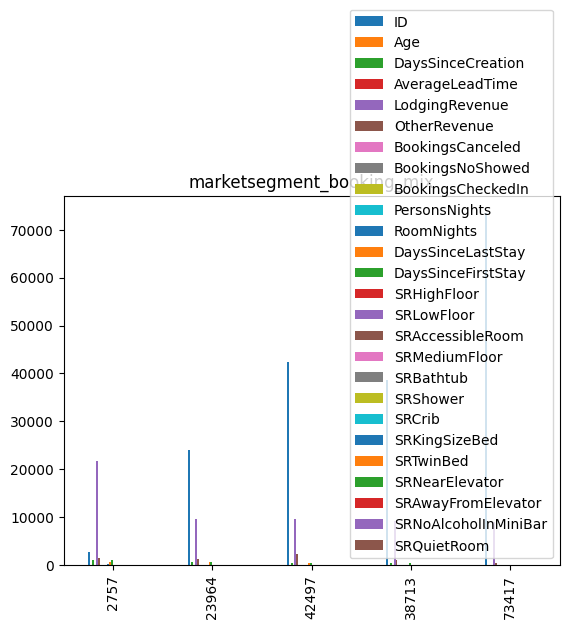

In [13]:
q3.plot(kind="bar")
plt.title("marketsegment_booking_mix")

In [14]:
plt.tight_layout()
plt.savefig("q10_marketsegment_booking_mix.png")
plt.show()

<Figure size 640x480 with 0 Axes>

## Final business insights

Write 3 short business insights here after completing Q9 and Q10.
